In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [2]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [3]:
gw=35

data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    887
0.077296      1
0.043449      1
0.085977      1
0.120078      1
           ... 
1.321421      1
0.100665      1
0.038671      1
0.127653      1
0.102933      1
Name: count, Length: 547, dtype: int64


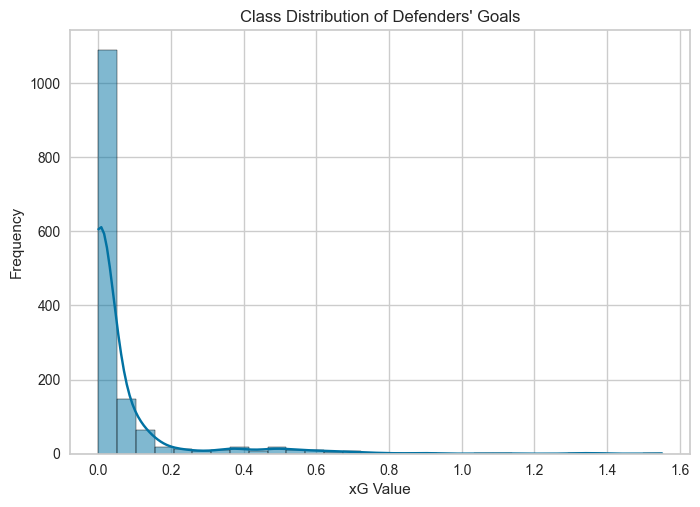

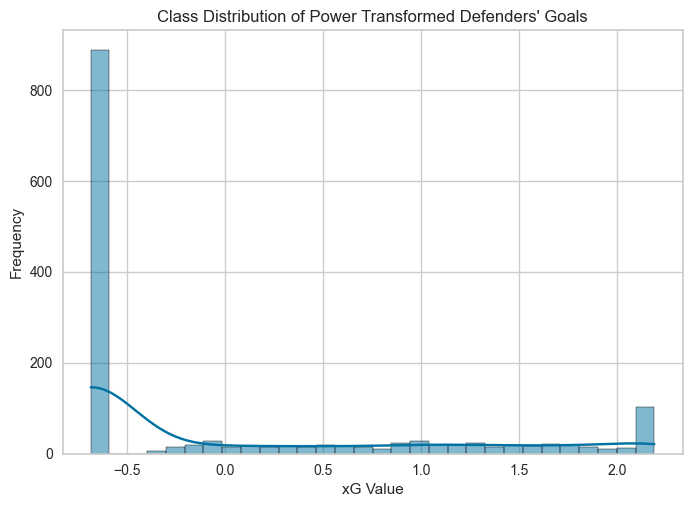

In [6]:
## TODO: XG PER 90????
def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [7]:
def_xg_data

,xG,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,percenatge_net_transfers,ict_index,influence,...,xG_5,xA_5,assists_x_5,assists_y_5,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5
0,1.237024,0.618,0.225,0.157,False,2,4,-0.383192,3.2,10.0,...,0.01,0.01,0.0,0.0,0.2,0.0,0.01,0.12,0.12,1.76
1,0.567001,0.526,0.249,0.225,True,2,2,0.639204,0.6,0.0,...,0.02,0.01,0.0,0.0,0.2,0.0,0.02,0.14,0.12,1.92
2,-0.682577,0.344,0.305,0.351,False,2,2,-0.402459,0.7,2.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.15,0.13,1.76
3,0.699870,0.572,0.227,0.201,False,2,4,-0.544130,0.0,0.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.13,0.11,1.46
4,-0.682577,0.579,0.239,0.182,False,2,3,-0.490372,2.0,15.6,...,0.04,0.00,0.0,0.0,0.0,0.0,0.04,0.10,0.08,1.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1.956225,0.431,0.306,0.263,False,2,2,-0.067259,3.1,22.0,...,0.13,0.06,0.0,0.0,0.2,0.2,0.13,0.09,0.03,2.38
1429,1.517547,0.572,0.255,0.174,True,2,2,0.772846,2.0,12.2,...,0.12,0.06,0.0,0.0,0.2,0.2,0.12,0.22,0.15,2.68
1430,-0.682577,0.745,0.167,0.087,False,2,5,-0.113902,4.0,27.0,...,0.11,0.06,0.0,0.0,0.2,0.0,0.11,0.27,0.22,3.22
1431,-0.682577,0.506,0.260,0.234,False,2,3,-0.286458,1.0,7.8,...,0.11,0.07,0.0,0.0,0.4,0.0,0.11,0.27,0.22,3.08


In [8]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4252
[LightGBM] [Info] Number of data points in the train set: 1146, number of used features: 68
[LightGBM] [Info] Start training from score -0.005084
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,Description,Value
0,Session id,6752
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1433, 93)"
4,Transformed data shape,"(1433, 19)"
5,Transformed train set shape,"(1146, 19)"
6,Transformed test set shape,"(287, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3180,0.2992,0.5447,0.6994,0.2379,0.9353,0.8600
rf,Random Forest Regressor,0.3186,0.2939,0.5399,0.7047,0.2427,0.9544,1.1110
gbr,Gradient Boosting Regressor,0.3529,0.3082,0.5522,0.6914,0.2527,1.0606,0.8790
xgboost,Extreme Gradient Boosting,0.3538,0.3446,0.5841,0.6527,0.2464,0.9810,0.8540
lightgbm,Light Gradient Boosting Machine,0.3662,0.3426,0.5836,0.6550,0.2518,1.0320,0.9350
dt,Decision Tree Regressor,0.4152,0.5783,0.7553,0.4217,0.2719,1.3286,0.8790
huber,Huber Regressor,0.4178,0.4777,0.6849,0.5252,0.3115,0.7795,0.5570
ada,AdaBoost Regressor,0.4198,0.3421,0.5806,0.6560,0.2884,1.0409,0.7260
knn,K Neighbors Regressor,0.4452,0.4881,0.6947,0.5107,0.2923,0.9064,0.4940
lr,Linear Regression,0.4891,0.4488,0.6655,0.5530,0.3353,0.8068,1.9640


ExtraTreesRegressor(n_jobs=-1, random_state=6752)

In [9]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

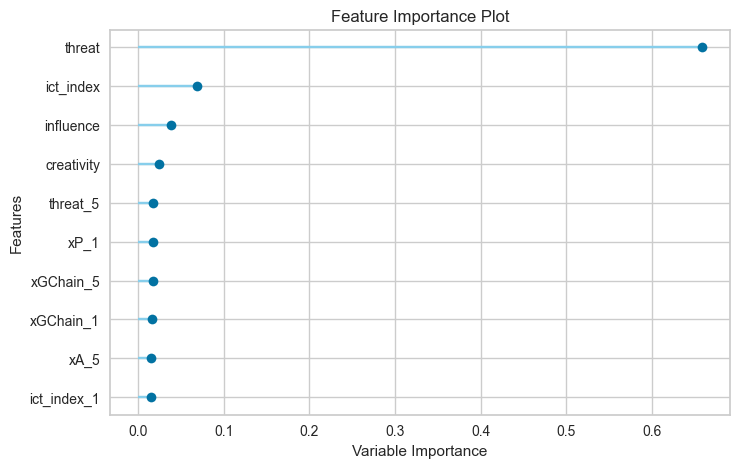

In [10]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [11]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [12]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [13]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    475
0.761169      4
0.098885      1
0.254050      1
0.148177      1
           ... 
0.036967      1
0.063258      1
0.041104      1
0.109722      1
0.121570      1
Name: count, Length: 985, dtype: int64


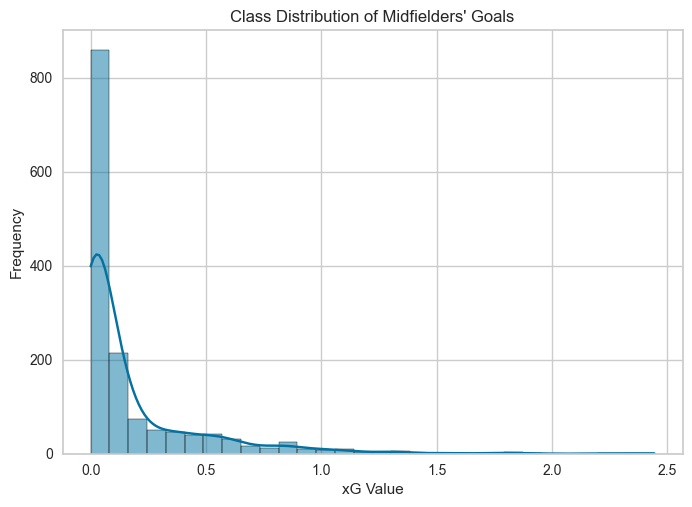

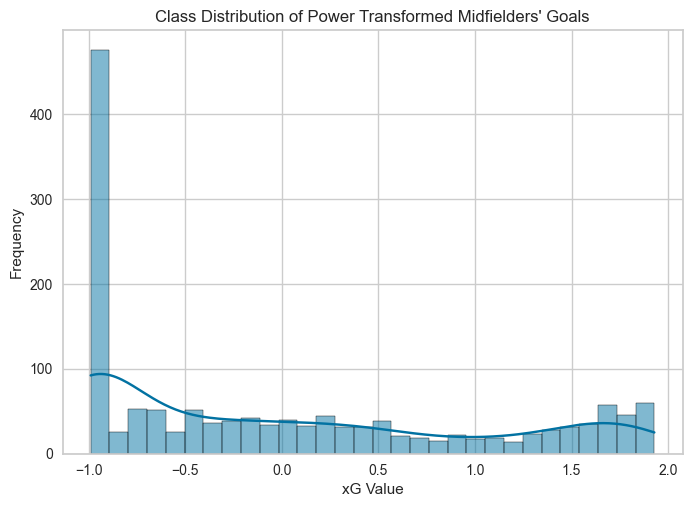

In [14]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [15]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5399
[LightGBM] [Info] Number of data points in the train set: 1169, number of used features: 71
[LightGBM] [Info] Start training from score -0.008743


,Description,Value
0,Session id,7042
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1462, 93)"
4,Transformed data shape,"(1462, 19)"
5,Transformed train set shape,"(1169, 19)"
6,Transformed test set shape,"(293, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3569,0.2733,0.5215,0.7231,0.2569,3.2692,1.0670
rf,Random Forest Regressor,0.3612,0.2813,0.5293,0.7146,0.2657,3.2603,1.3450
gbr,Gradient Boosting Regressor,0.3684,0.2802,0.5283,0.7156,0.2631,3.0716,0.9160
lightgbm,Light Gradient Boosting Machine,0.3706,0.2908,0.5382,0.7051,0.2643,3.1945,1.1780
xgboost,Extreme Gradient Boosting,0.3934,0.3277,0.5716,0.6678,0.2707,3.2785,0.9190
huber,Huber Regressor,0.4460,0.3994,0.6298,0.5949,0.2804,2.6462,1.3940
knn,K Neighbors Regressor,0.4474,0.3665,0.6042,0.6293,0.2929,3.2496,1.0360
ada,AdaBoost Regressor,0.4618,0.3279,0.5722,0.6677,0.2885,2.9795,0.8260
lr,Linear Regression,0.4719,0.3808,0.6163,0.6137,0.2946,2.4806,1.5310
ridge,Ridge Regression,0.4720,0.3798,0.6155,0.6148,0.2945,2.4316,0.6180


ExtraTreesRegressor(n_jobs=-1, random_state=7042)

In [16]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

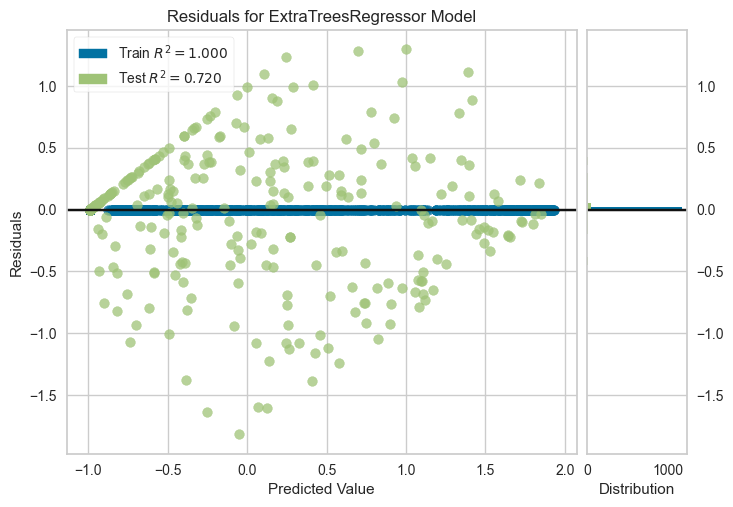

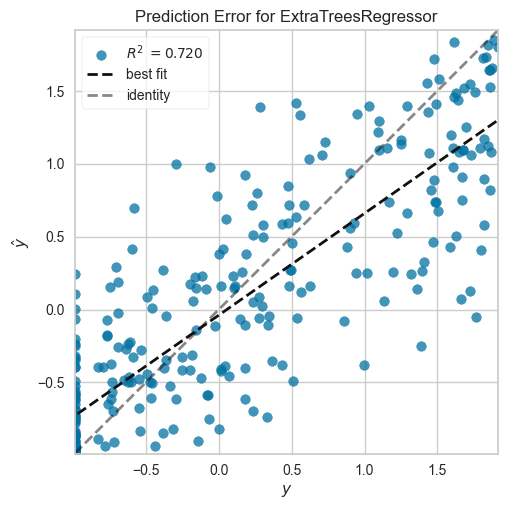

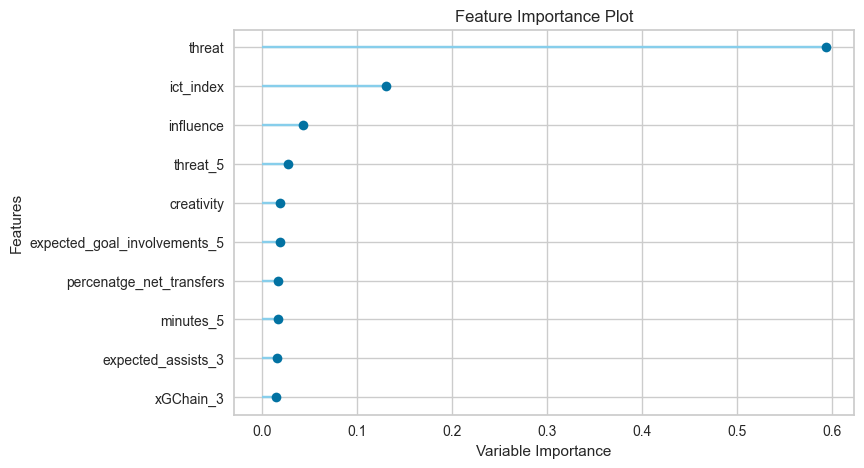

In [17]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [18]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3932,0.2884,0.5370,0.7174,0.2982,1.0223
1,0.3212,0.2423,0.4923,0.7688,0.2436,8.3852
2,0.3460,0.2753,0.5247,0.7228,0.2472,1.4585
3,0.4064,0.3066,0.5537,0.6543,0.2919,1.7522
4,0.3098,0.2135,0.4620,0.7870,0.2213,1.0266
5,0.3423,0.3156,0.5618,0.6866,0.2345,3.4864
6,0.3838,0.3150,0.5612,0.7222,0.2637,1.7126
7,0.3550,0.2762,0.5255,0.7138,0.2436,10.1794
8,0.3749,0.2870,0.5357,0.6816,0.2616,1.7486


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [19]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    93
0.100277     1
0.141245     1
0.410759     1
0.030086     1
            ..
0.739986     1
0.525393     1
0.823317     1
0.134095     1
0.371195     1
Name: count, Length: 367, dtype: int64


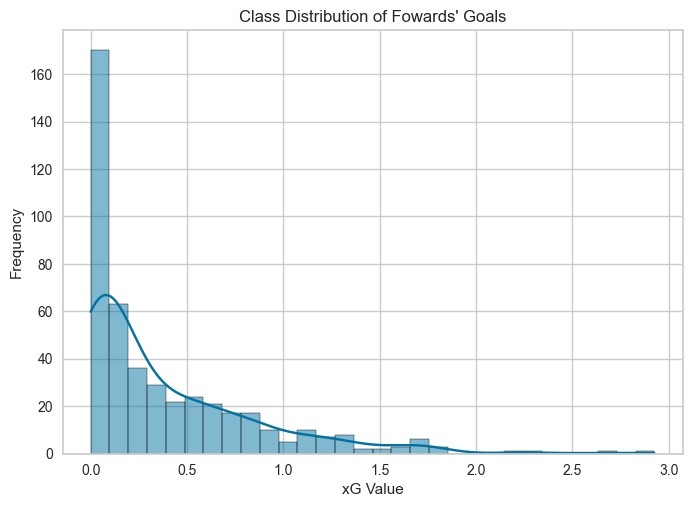

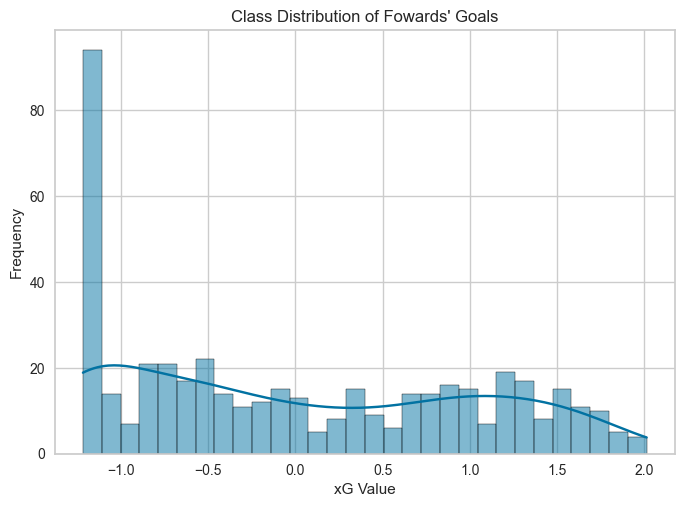

In [20]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2675
[LightGBM] [Info] Number of data points in the train set: 367, number of used features: 65
[LightGBM] [Info] Start training from score 0.010104
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Description,Value
0,Session id,5062
1,Target,xG
2,Target type,Regression
3,Original data shape,"(459, 93)"
4,Transformed data shape,"(459, 19)"
5,Transformed train set shape,"(367, 19)"
6,Transformed test set shape,"(92, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.4523,0.3440,0.5821,0.6293,0.2747,2.1108,0.5460
et,Extra Trees Regressor,0.4591,0.3436,0.5821,0.6288,0.2787,1.8658,0.4860
xgboost,Extreme Gradient Boosting,0.4909,0.4237,0.6439,0.5481,0.2780,2.3128,0.4440
lightgbm,Light Gradient Boosting Machine,0.4936,0.3955,0.6235,0.5697,0.2854,2.3724,0.6000
gbr,Gradient Boosting Regressor,0.4946,0.4053,0.6320,0.5615,0.2785,2.6089,0.4220
knn,K Neighbors Regressor,0.4964,0.4002,0.6294,0.5665,0.2837,2.1539,0.3080
omp,Orthogonal Matching Pursuit,0.5052,0.3833,0.6147,0.5918,0.2912,1.4889,0.3040
br,Bayesian Ridge,0.5066,0.3789,0.6112,0.5961,0.2864,1.9780,0.2980
en,Elastic Net,0.5089,0.3805,0.6130,0.5946,0.2919,1.6179,0.3590
huber,Huber Regressor,0.5108,0.4159,0.6383,0.5565,0.2846,3.1399,0.3240


RandomForestRegressor(n_jobs=-1, random_state=5062)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


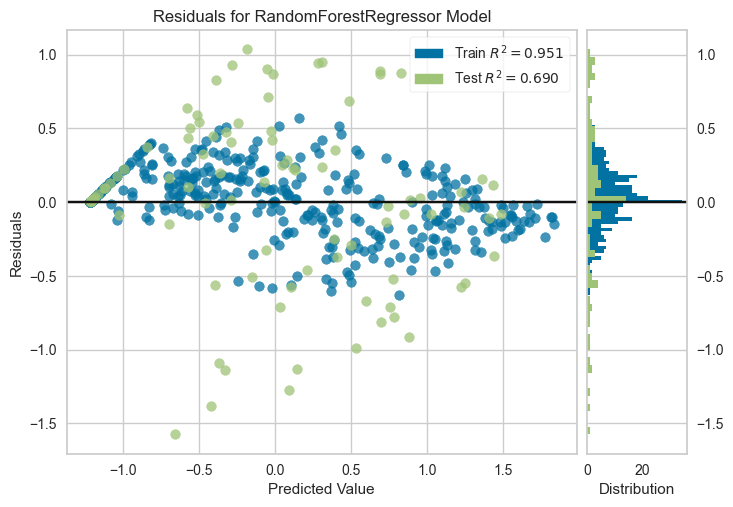

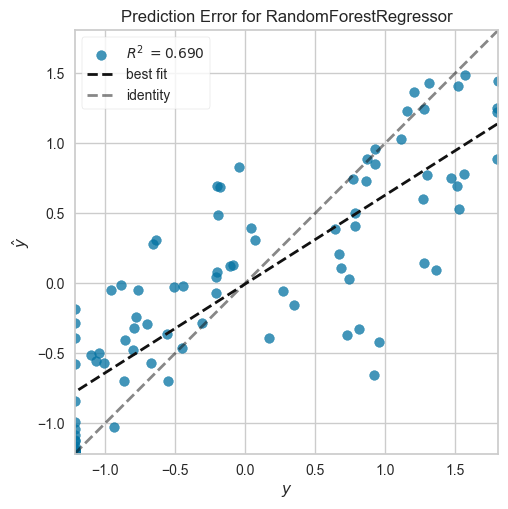

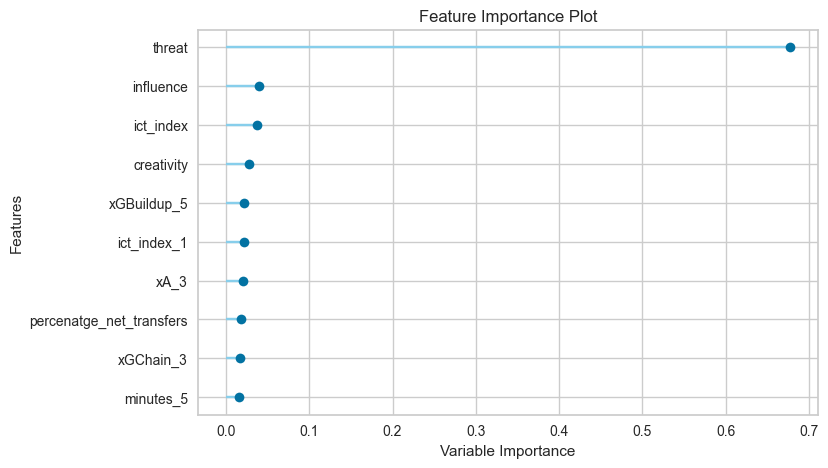

In [21]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [22]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3989,0.2608,0.5107,0.7276,0.2346,2.8875
1,0.4058,0.2862,0.5350,0.7443,0.2236,1.3406
2,0.4920,0.4041,0.6357,0.5675,0.2780,6.1123
3,0.6013,0.6091,0.7804,0.2910,0.2545,2.0966
4,0.4687,0.3340,0.5779,0.5276,0.3060,0.8461
5,0.5746,0.5952,0.7715,0.3456,0.2669,1.2250
6,0.4251,0.3277,0.5725,0.5883,0.2661,0.6119
7,0.4501,0.3277,0.5725,0.6979,0.2939,0.5189
8,0.4819,0.3324,0.5766,0.7149,0.2733,0.6832


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [23]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [24]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    968
0.890411      1
0.037738      1
0.031754      1
0.077340      1
           ... 
0.089094      1
0.350111      1
0.161361      1
0.114987      1
0.055309      1
Name: count, Length: 466, dtype: int64


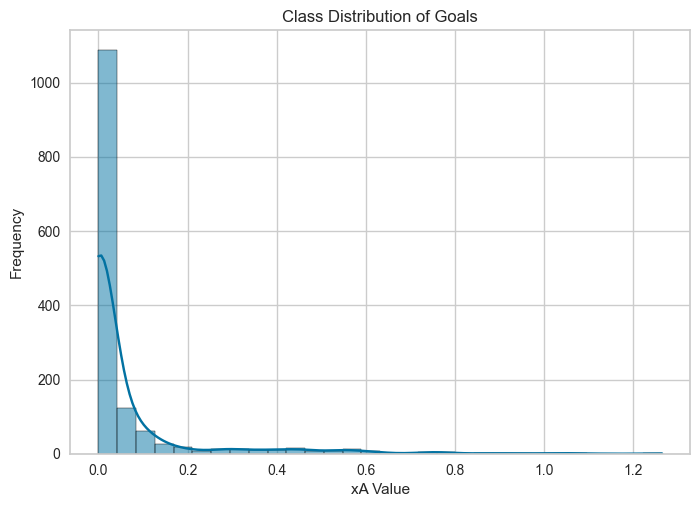

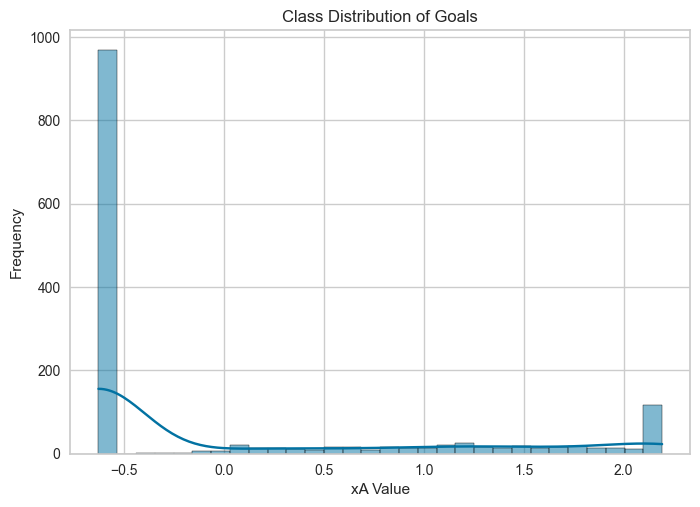

In [25]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4546
[LightGBM] [Info] Number of data points in the train set: 1146, number of used features: 64
[LightGBM] [Info] Start training from score 0.005768
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,180
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1433, 76)"
4,Transformed data shape,"(1433, 16)"
5,Transformed train set shape,"(1146, 16)"
6,Transformed test set shape,"(287, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1809,0.1559,0.3905,0.8447,0.1786,0.5902,0.9310
et,Extra Trees Regressor,0.1825,0.1491,0.3830,0.8518,0.1785,0.5799,0.6130
xgboost,Extreme Gradient Boosting,0.2003,0.1792,0.4203,0.8225,0.1948,0.6045,0.6950
gbr,Gradient Boosting Regressor,0.2026,0.1673,0.4049,0.8338,0.1857,0.6396,0.9090
lightgbm,Light Gradient Boosting Machine,0.2058,0.1703,0.4085,0.8303,0.1921,0.6208,0.8500
knn,K Neighbors Regressor,0.2124,0.2025,0.4486,0.7988,0.2075,0.5553,0.4820
dt,Decision Tree Regressor,0.2246,0.2613,0.5049,0.7385,0.2311,0.6203,0.4470
ada,AdaBoost Regressor,0.2468,0.1851,0.4279,0.8169,0.1945,0.7207,0.5150
huber,Huber Regressor,0.3352,0.4129,0.6387,0.5827,0.2851,0.4157,0.5020
br,Bayesian Ridge,0.4111,0.3818,0.6160,0.6152,0.3005,0.5689,0.5720


RandomForestRegressor(n_jobs=-1, random_state=180)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


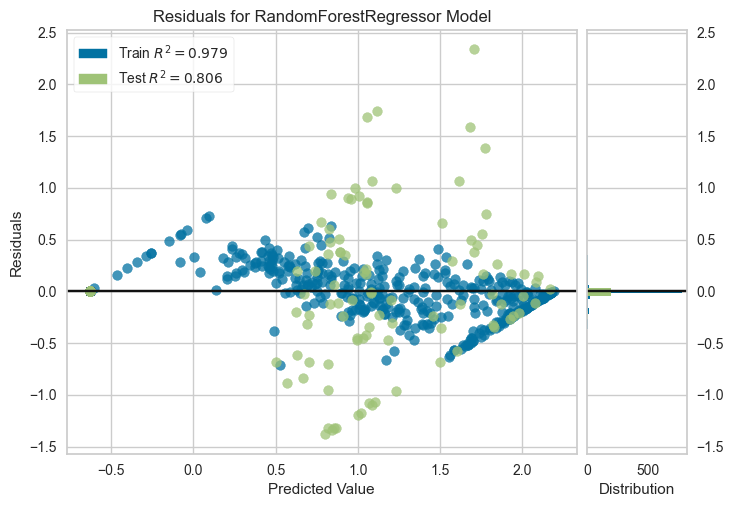

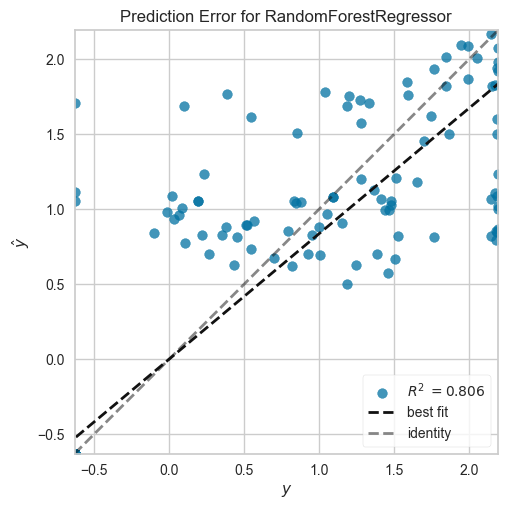

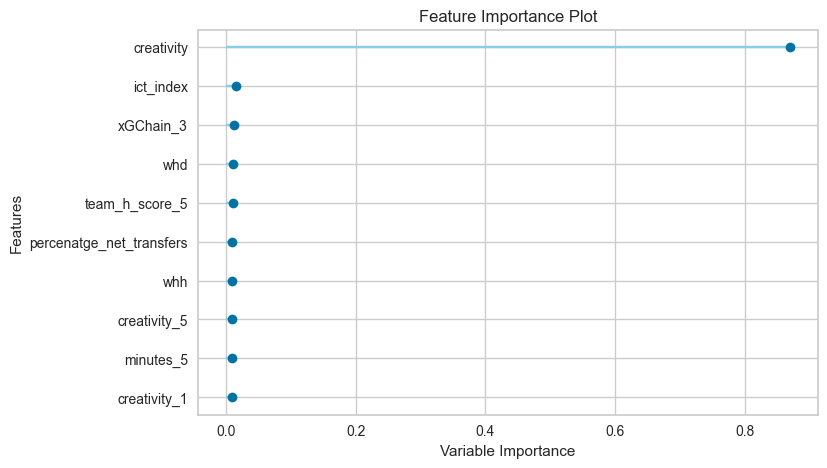

In [26]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [27]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1643,0.1518,0.3896,0.8653,0.1563,0.5864
1,0.1813,0.1411,0.3756,0.8746,0.1634,0.2928
2,0.2427,0.2601,0.5100,0.7455,0.2210,0.5416
3,0.1354,0.0947,0.3077,0.9082,0.1413,0.3192
4,0.2163,0.1781,0.4220,0.8269,0.1997,0.5835
5,0.1567,0.1285,0.3585,0.8393,0.1804,0.8156
6,0.1546,0.1191,0.3451,0.8775,0.1689,0.5469
7,0.1615,0.1312,0.3622,0.8719,0.1570,0.3562
8,0.1803,0.1331,0.3648,0.8708,0.1844,0.5082


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [28]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    594
0.027188      1
0.014364      1
0.014649      1
0.187261      1
           ... 
0.516406      1
0.268133      1
0.020133      1
0.613722      1
0.048324      1
Name: count, Length: 869, dtype: int64


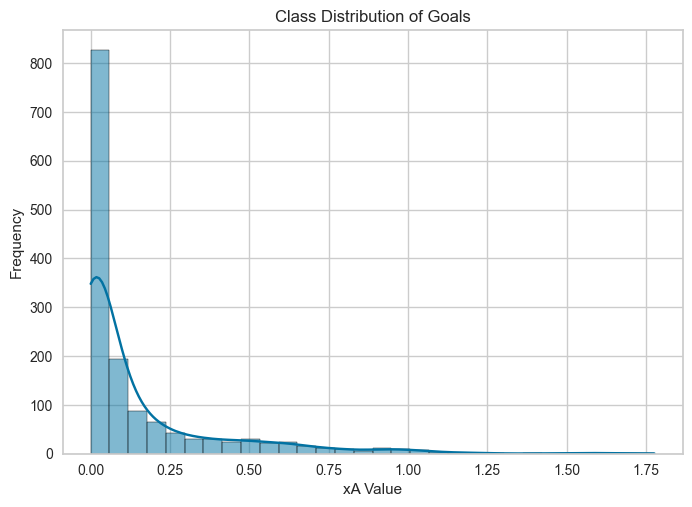

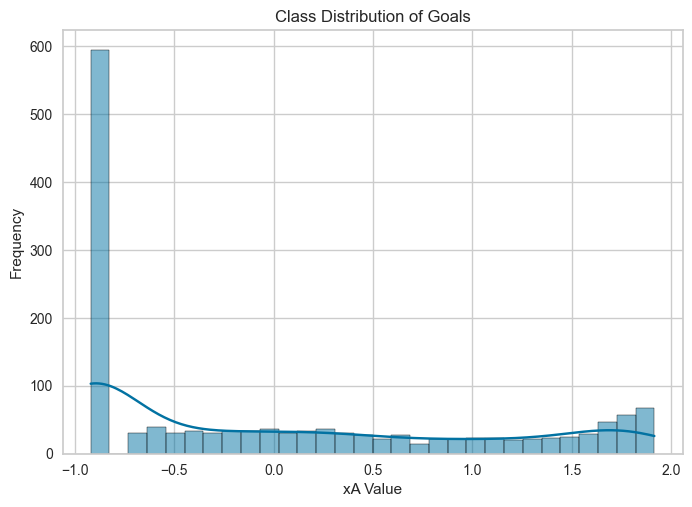

In [29]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6030
[LightGBM] [Info] Number of data points in the train set: 1169, number of used features: 66
[LightGBM] [Info] Start training from score 0.009765


,Description,Value
0,Session id,4239
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1462, 76)"
4,Transformed data shape,"(1462, 16)"
5,Transformed train set shape,"(1169, 16)"
6,Transformed test set shape,"(293, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3536,0.3015,0.5479,0.6974,0.2674,1.5066,0.8770
et,Extra Trees Regressor,0.3581,0.3028,0.5487,0.6967,0.2701,1.5121,0.6810
gbr,Gradient Boosting Regressor,0.3710,0.3072,0.5523,0.6922,0.2738,1.5489,0.8490
lightgbm,Light Gradient Boosting Machine,0.3813,0.3343,0.5760,0.6654,0.2660,1.6073,1.0520
xgboost,Extreme Gradient Boosting,0.3848,0.3338,0.5748,0.6657,0.2643,1.5354,0.8360
ada,AdaBoost Regressor,0.3976,0.3277,0.5713,0.6716,0.2568,1.6971,0.7760
knn,K Neighbors Regressor,0.4188,0.3867,0.6195,0.6146,0.2913,1.3848,0.5520
huber,Huber Regressor,0.4215,0.3936,0.6260,0.6066,0.2898,1.2686,0.6710
br,Bayesian Ridge,0.4471,0.3696,0.6066,0.6305,0.3044,1.2403,0.5250
ridge,Ridge Regression,0.4489,0.3736,0.6097,0.6268,0.3040,1.2284,0.6380


RandomForestRegressor(n_jobs=-1, random_state=4239)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


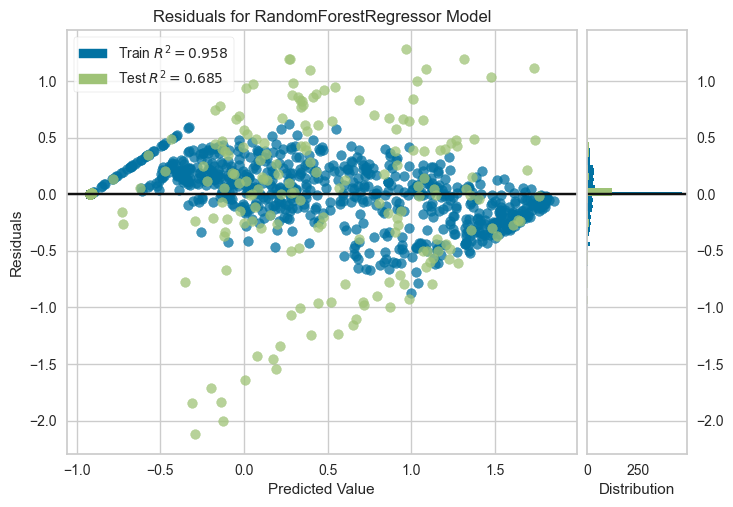

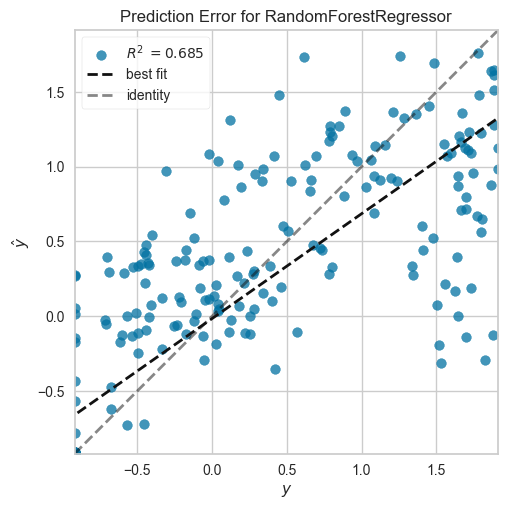

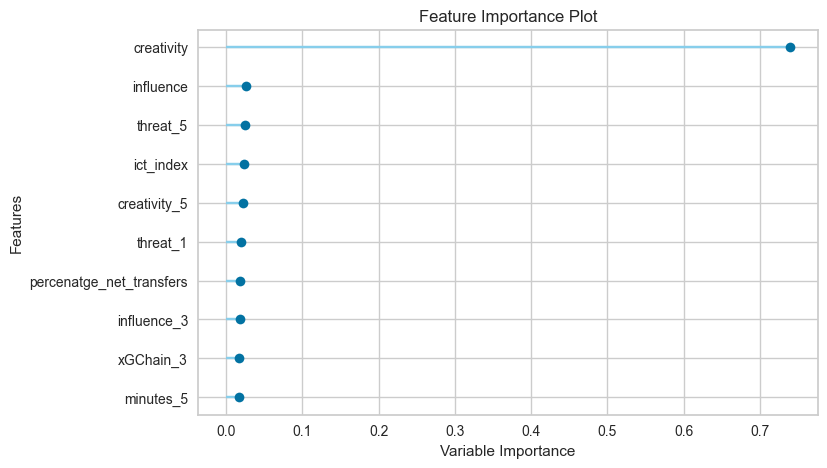

In [30]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [31]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4721,0.5346,0.7312,0.4863,0.2832,3.3275
1,0.4137,0.4825,0.6946,0.4047,0.2405,2.3631
2,0.4101,0.3853,0.6207,0.6251,0.2355,0.9597
3,0.4052,0.4615,0.6793,0.5091,0.2362,4.8330
4,0.4071,0.4107,0.6408,0.5922,0.2367,2.5143
5,0.4466,0.4638,0.6811,0.6094,0.2460,0.8165
6,0.3891,0.3821,0.6181,0.6449,0.2402,3.5620
7,0.3920,0.3936,0.6274,0.6294,0.2458,2.9214
8,0.3778,0.3529,0.5941,0.6416,0.2385,1.2588


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [32]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    217
0.027098      1
0.444472      1
0.029739      1
0.151797      1
           ... 
0.018458      1
0.087106      1
0.066920      1
0.028647      1
0.294103      1
Name: count, Length: 243, dtype: int64


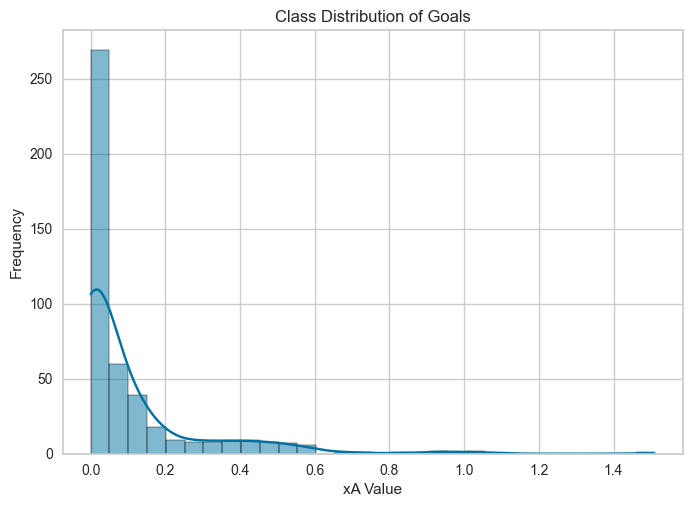

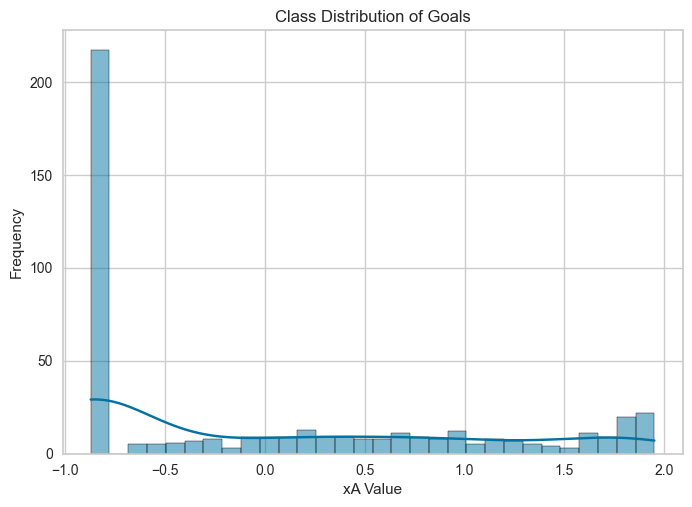

In [33]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2981
[LightGBM] [Info] Number of data points in the train set: 367, number of used features: 66
[LightGBM] [Info] Start training from score -0.021812
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Description,Value
0,Session id,8480
1,Target,xA
2,Target type,Regression
3,Original data shape,"(459, 76)"
4,Transformed data shape,"(459, 16)"
5,Transformed train set shape,"(367, 16)"
6,Transformed test set shape,"(92, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3204,0.2739,0.5199,0.7113,0.2330,1.0761,0.4620
et,Extra Trees Regressor,0.3275,0.2794,0.5231,0.7092,0.2343,1.0197,0.3780
xgboost,Extreme Gradient Boosting,0.3527,0.3221,0.5648,0.6561,0.2589,1.0614,0.4420
ada,AdaBoost Regressor,0.3595,0.2889,0.5347,0.6931,0.2471,1.1655,0.2550
lightgbm,Light Gradient Boosting Machine,0.3597,0.2948,0.5413,0.6852,0.2490,1.0279,0.2530
gbr,Gradient Boosting Regressor,0.3650,0.3072,0.5496,0.6751,0.2534,1.1374,0.3650
dt,Decision Tree Regressor,0.4060,0.4984,0.7016,0.4610,0.2999,1.6540,0.2980
knn,K Neighbors Regressor,0.4207,0.4033,0.6250,0.5894,0.2816,0.9974,0.3880
huber,Huber Regressor,0.4243,0.4267,0.6353,0.5779,0.3090,0.6784,0.2780
ridge,Ridge Regression,0.4693,0.4096,0.6272,0.5890,0.3273,0.7203,0.2110


RandomForestRegressor(n_jobs=-1, random_state=8480)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


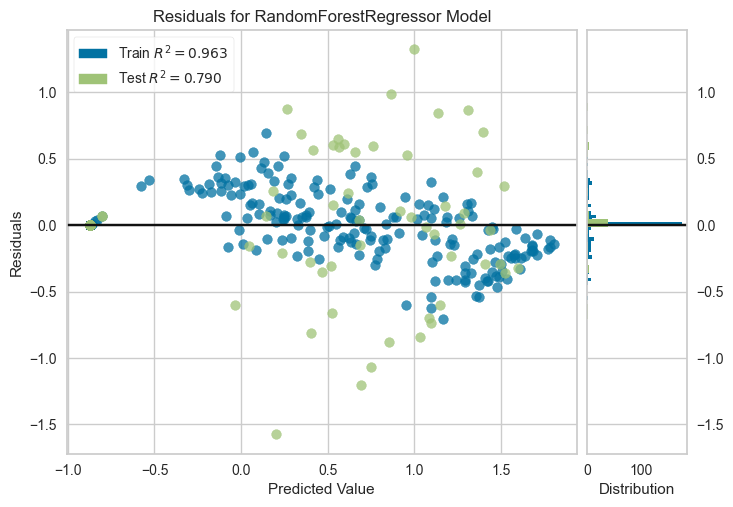

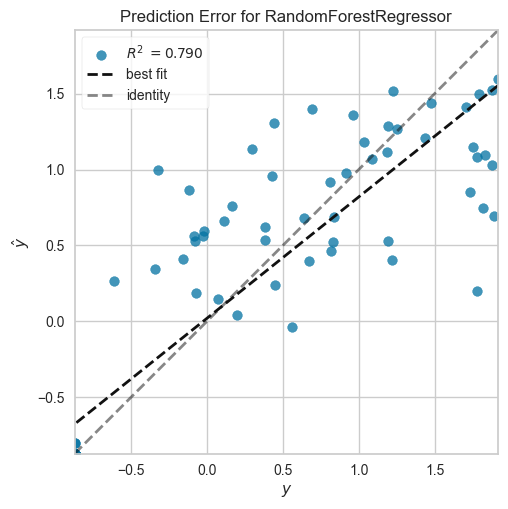

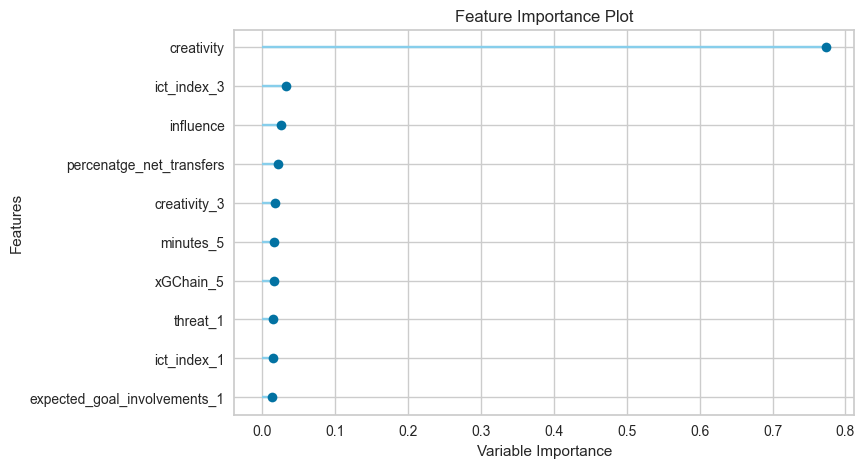

In [34]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [35]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3336,0.3592,0.5994,0.6426,0.2731,0.6588
1,0.4844,0.5202,0.7213,0.6159,0.2622,0.6747
2,0.2987,0.2597,0.5096,0.8003,0.2776,0.3239
3,0.3877,0.3767,0.6138,0.5473,0.2632,0.9014
4,0.3610,0.3304,0.5748,0.6920,0.3016,2.5166
5,0.2893,0.2778,0.5271,0.5718,0.2296,1.0167
6,0.1589,0.1010,0.3178,0.8985,0.1487,0.9167
7,0.3029,0.2415,0.4915,0.6735,0.2234,1.7966
8,0.3440,0.3322,0.5763,0.6697,0.2707,0.6915


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [36]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     81
3     75
4     62
1     43
5     33
6     20
0     15
7     12
8     11
9      6
10     4
12     1
Name: count, dtype: int64


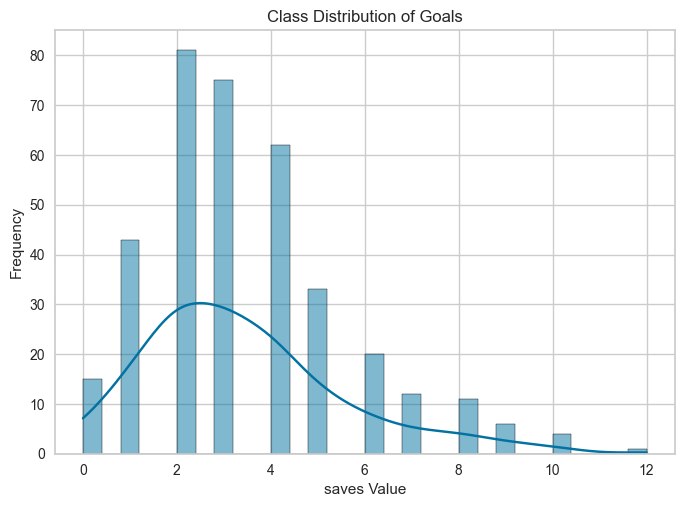

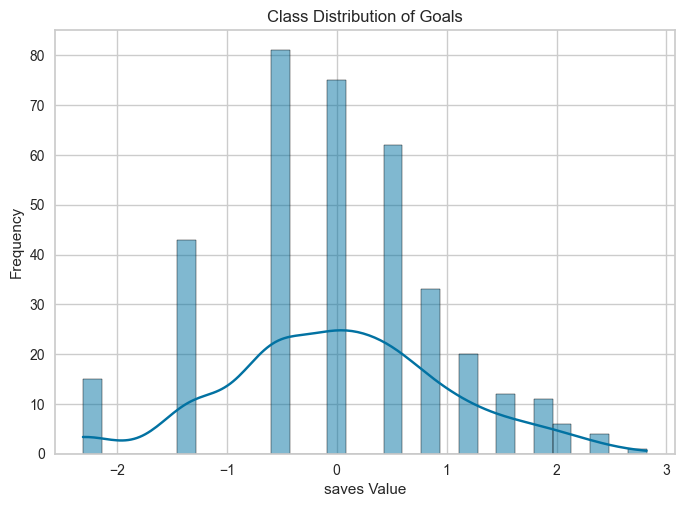

In [37]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1362
[LightGBM] [Info] Number of data points in the train set: 290, number of used features: 42
[LightGBM] [Info] Start training from score 0.004198
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,4358
1,Target,saves
2,Target type,Regression
3,Original data shape,"(363, 75)"
4,Transformed data shape,"(363, 15)"
5,Transformed train set shape,"(290, 15)"
6,Transformed test set shape,"(73, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2498,0.1049,0.3215,0.8815,0.1850,1.4703,0.3010
rf,Random Forest Regressor,0.2550,0.1065,0.3242,0.8786,0.1862,1.4156,0.3630
et,Extra Trees Regressor,0.2561,0.1096,0.3278,0.8755,0.1833,1.4498,0.3230
ada,AdaBoost Regressor,0.2672,0.1157,0.3373,0.8671,0.1891,1.2271,0.2800
xgboost,Extreme Gradient Boosting,0.2772,0.1302,0.3580,0.8507,0.1976,1.6308,0.2780
en,Elastic Net,0.2975,0.1491,0.3833,0.8369,0.1924,1.3722,0.2340
lasso,Lasso Regression,0.2986,0.1522,0.3871,0.8341,0.1954,1.3344,0.0990
llar,Lasso Least Angle Regression,0.2986,0.1522,0.3871,0.8341,0.1954,1.3344,0.2280
lightgbm,Light Gradient Boosting Machine,0.3006,0.1497,0.3836,0.8307,0.2053,1.5778,0.3260
br,Bayesian Ridge,0.3006,0.1501,0.3846,0.8354,0.1929,1.4320,0.2290


GradientBoostingRegressor(random_state=4358)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


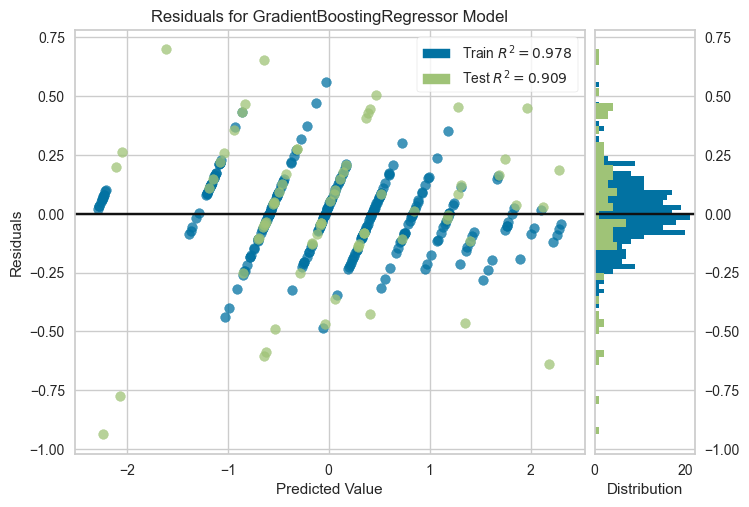

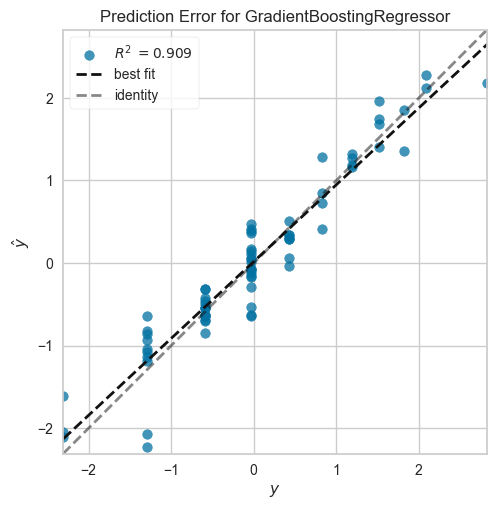

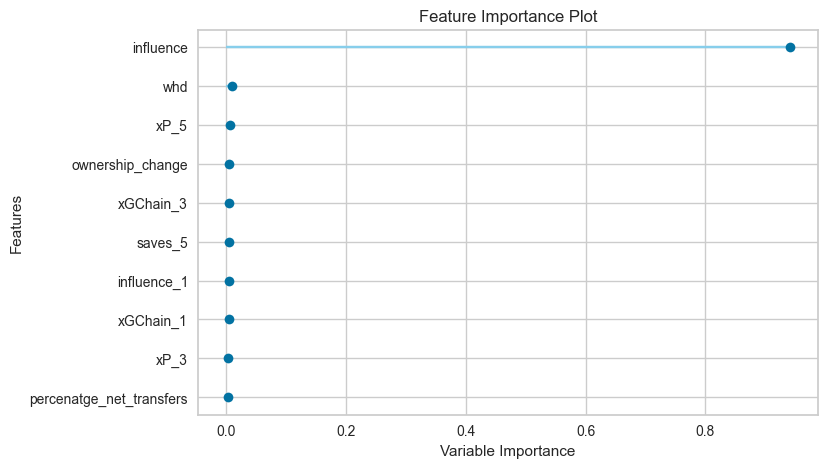

In [38]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [39]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2559,0.0947,0.3077,0.8808,0.2070,0.9712
1,0.2440,0.0831,0.2882,0.9329,0.1721,1.9040
2,0.2998,0.1447,0.3805,0.8673,0.2046,1.3468
3,0.2395,0.1202,0.3467,0.8336,0.1935,2.3880
4,0.2043,0.0783,0.2799,0.9303,0.1485,1.1685
5,0.2470,0.0896,0.2994,0.9236,0.1563,1.1810
6,0.3235,0.1663,0.4078,0.7457,0.2249,2.2085
7,0.2925,0.1418,0.3765,0.8455,0.2192,1.7466
8,0.2382,0.0923,0.3038,0.9175,0.1795,1.4402


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [40]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [41]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.69    5
0.59    5
1.68    5
1.11    4
1.44    4
       ..
1.91    1
0.92    1
0.78    1
0.44    1
2.99    1
Name: count, Length: 210, dtype: int64


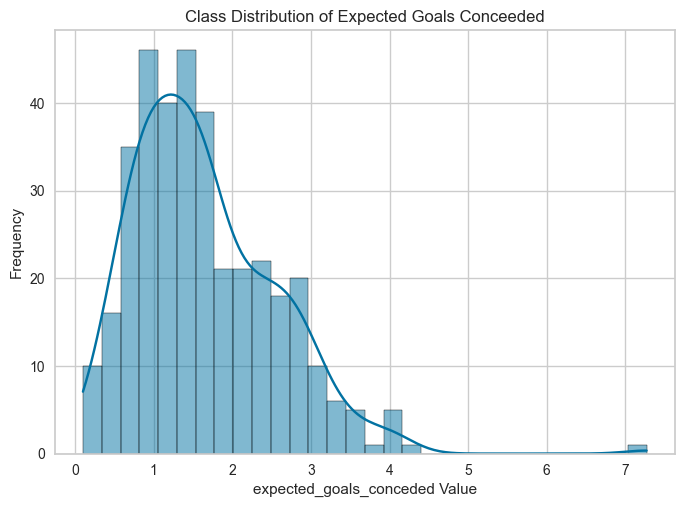

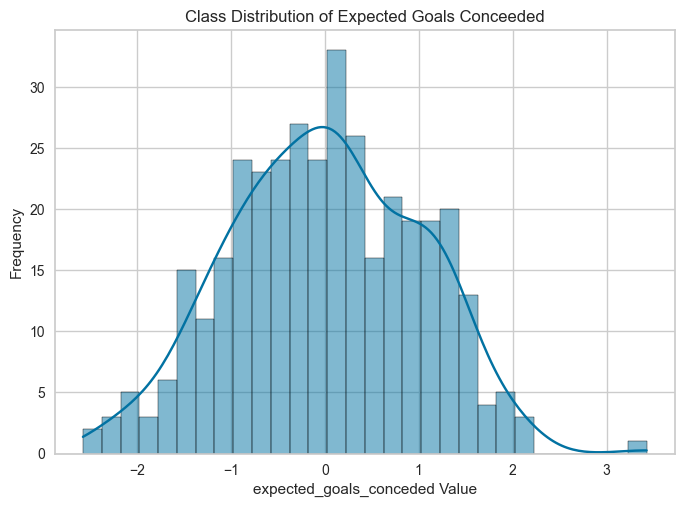

In [42]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1294
[LightGBM] [Info] Number of data points in the train set: 290, number of used features: 42
[LightGBM] [Info] Start training from score -0.011409
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Description,Value
0,Session id,1298
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(363, 70)"
4,Transformed data shape,"(363, 14)"
5,Transformed train set shape,"(290, 14)"
6,Transformed test set shape,"(73, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7362,0.7821,0.8813,0.1250,0.4213,1.8414,0.1030
lasso,Lasso Regression,0.7380,0.7763,0.8756,0.1465,0.4367,1.7581,0.1930
llar,Lasso Least Angle Regression,0.7380,0.7763,0.8756,0.1465,0.4367,1.7581,0.1220
en,Elastic Net,0.7382,0.7727,0.8740,0.1461,0.4290,1.8395,0.1000
lr,Linear Regression,0.7390,0.7867,0.8836,0.1220,0.4196,1.8362,0.2020
br,Bayesian Ridge,0.7394,0.7745,0.8753,0.1410,0.4243,1.8962,0.0950
et,Extra Trees Regressor,0.7420,0.8086,0.8965,0.0785,0.4135,2.0665,0.3260
huber,Huber Regressor,0.7453,0.8403,0.9093,0.0854,0.4501,1.8501,0.1290
lar,Least Angle Regression,0.7456,0.7961,0.8886,0.1149,0.4170,1.8605,0.2540
rf,Random Forest Regressor,0.7492,0.8359,0.9106,0.0524,0.4111,2.0476,0.3450


Ridge(random_state=1298)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


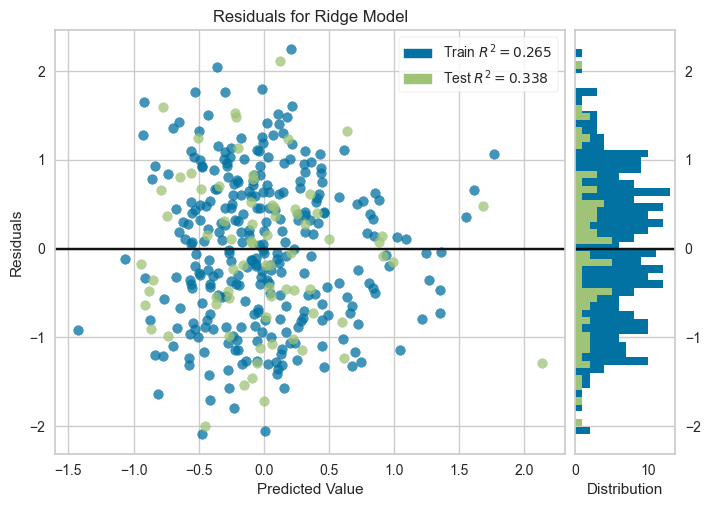

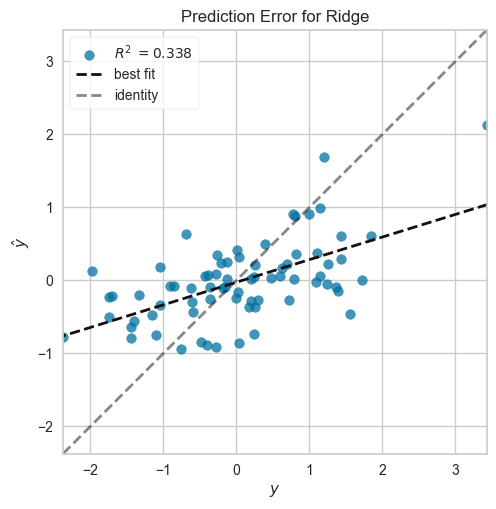

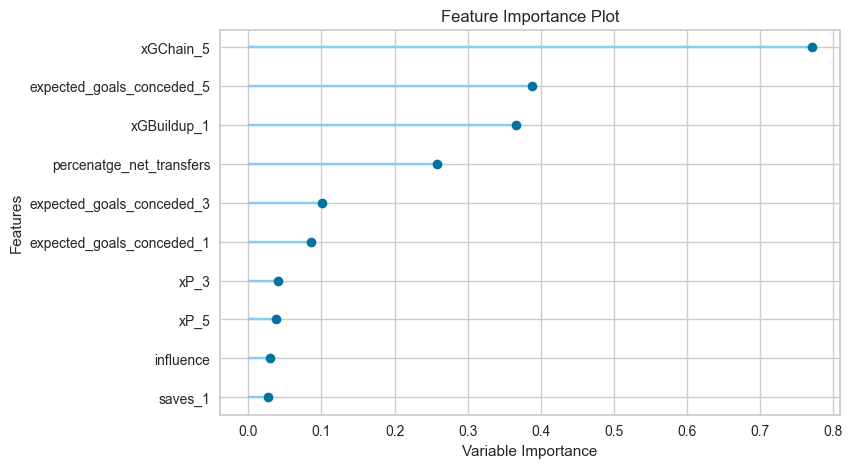

In [43]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [44]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8494,0.9932,0.9966,0.3769,0.5191,1.1576
1,0.7896,0.8124,0.9013,0.2979,0.4424,2.4980
2,0.7487,0.7823,0.8845,0.2427,0.4246,1.1512
3,0.8182,0.8888,0.9428,0.1295,0.4925,1.6340
4,0.7860,0.8346,0.9136,0.0518,0.3808,1.6023
5,0.6359,0.6150,0.7843,0.1332,0.3768,2.4406
6,0.7433,0.9086,0.9532,0.3181,0.4737,2.9276
7,0.7573,0.7886,0.8880,-0.0282,0.4365,1.2414
8,0.6405,0.5885,0.7671,0.0277,0.3880,1.1823


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [45]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Def


expected_goals_conceded
0.83    19
1.87    17
0.71    14
1.69    14
0.56    14
        ..
2.47     1
4.15     1
0.15     1
1.37     1
0.21     1
Name: count, Length: 297, dtype: int64


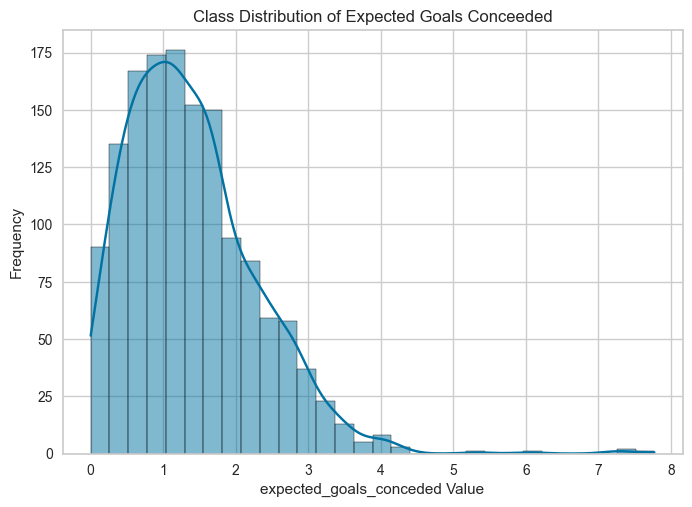

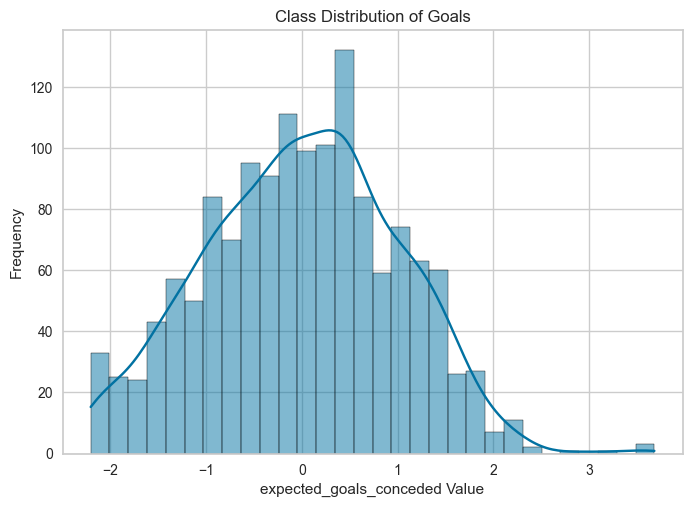

In [46]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5004
[LightGBM] [Info] Number of data points in the train set: 1146, number of used features: 57
[LightGBM] [Info] Start training from score -0.006998


,Description,Value
0,Session id,966
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1433, 70)"
4,Transformed data shape,"(1433, 14)"
5,Transformed train set shape,"(1146, 14)"
6,Transformed test set shape,"(287, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7240,0.8436,0.9162,0.1539,0.4020,2.2991,0.3550
rf,Random Forest Regressor,0.7244,0.8269,0.9072,0.1766,0.4368,1.5739,1.0970
et,Extra Trees Regressor,0.7246,0.8098,0.8979,0.1942,0.4342,1.7889,0.7910
xgboost,Extreme Gradient Boosting,0.7310,0.8450,0.9170,0.1528,0.4055,2.1254,0.3670
gbr,Gradient Boosting Regressor,0.7358,0.8434,0.9167,0.1604,0.4390,1.8435,0.4250
ridge,Ridge Regression,0.7788,0.9281,0.9623,0.0763,0.4741,1.6270,0.5140
lr,Linear Regression,0.7790,0.9289,0.9627,0.0757,0.4742,1.6248,0.5170
ada,AdaBoost Regressor,0.7797,0.9122,0.9540,0.0916,0.4890,1.7036,0.3160
br,Bayesian Ridge,0.7850,0.9326,0.9649,0.0711,0.4884,1.6179,0.7990
en,Elastic Net,0.8046,0.9626,0.9802,0.0421,0.5330,1.4824,0.7340


LGBMRegressor(n_jobs=-1, random_state=966)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


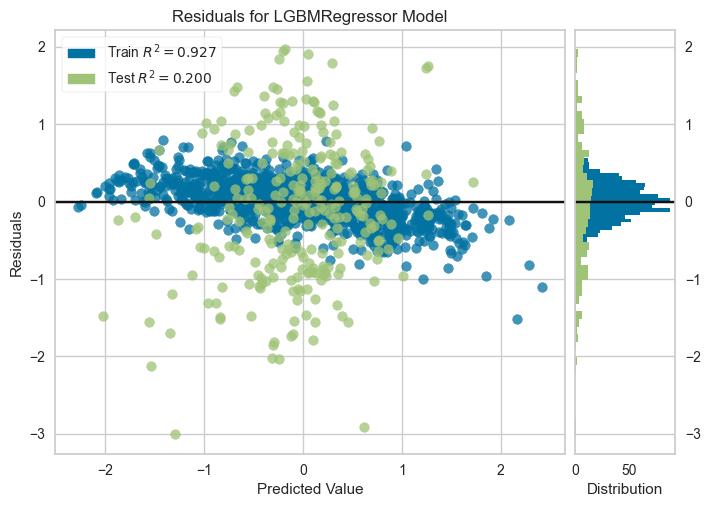

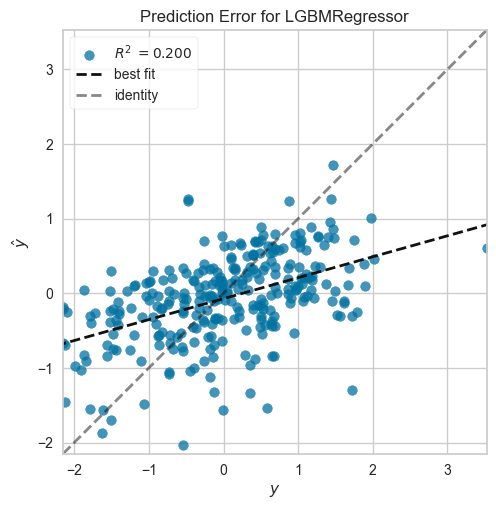

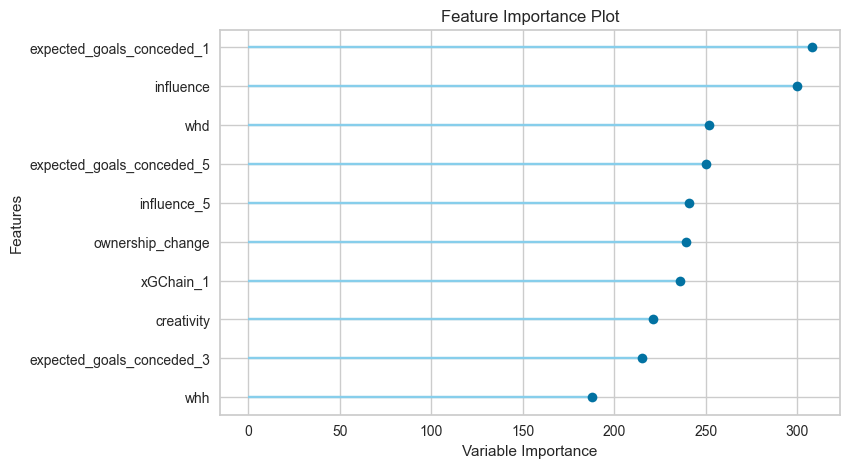

In [47]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [48]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7928,1.0234,1.0116,0.0625,0.4388,2.9528
1,0.7865,0.8880,0.9423,0.1429,0.4593,1.6771
2,0.7044,0.8512,0.9226,0.0311,0.3926,1.6673
3,0.6201,0.6233,0.7895,0.3469,0.3834,1.0826
4,0.7111,0.8728,0.9343,0.2033,0.4204,1.2544
5,0.7815,0.9222,0.9603,0.1892,0.4202,2.0064
6,0.6852,0.7261,0.8521,0.3552,0.4289,1.4244
7,0.7689,0.8567,0.9256,0.0469,0.3994,1.5407
8,0.7059,0.7812,0.8839,0.1600,0.3932,4.7483


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [49]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 